# 05. Feature Engineering Simplificado - Safras e Features Temporais

## 🎯 Objetivo

Implementar **feature engineering simplificado** focado em safras (YYYYMMDD) e 
componentes temporais básicos para análise de lavagem de dinheiro.

## 📚 Features Implementadas

### 1. **Safra (YYYYMMDD)**
- Safra no formato: 20220915 (ano + mês + dia)
- Facilita agrupamento e análise temporal

### 2. **Componentes Temporais**
- Ano, Mês, Dia, Hora, Dia da Semana
- Features cíclicas para capturar sazonalidade

### 3. **Features de Negócio**
- is_weekend (fim de semana)
- is_business_hours (horário comercial: 9h-18h)
- is_night (horário noturno: 0h-6h)

## ⚠️ Abordagem Simplificada

✅ **Sem features de velocidade complexas** (rolling windows)  
✅ **Sem ratio features** (comparação com histórico)  
✅ **Foco em safras e padrões temporais básicos**  
✅ **Pipeline mais leve e rápido**

---

## 1. Setup - Importações e Configuração

In [11]:
# Configurar path para importar módulos do projeto
import sys
from pathlib import Path

notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    sys.path.insert(0, str(notebook_dir.parent))

# Importar configurações do projeto
from source.config import PROJ_ROOT, get_data_path, ensure_directories

# Garantir que os diretórios existam
ensure_directories()

print(f"✅ Projeto Root: {PROJ_ROOT}")
print(f"✅ Configurações carregadas de source/config.py")

✅ Projeto Root: C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering
✅ Configurações carregadas de source/config.py


In [12]:
# Importações padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import json

# Configurações
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas importadas com sucesso!")
print("✅ Feature Engineering Simplificado!")

✅ Bibliotecas importadas com sucesso!
✅ Feature Engineering Simplificado!


## 2. Carregamento dos Dados (Treino e OOT)

⚠️ **IMPORTANTE**: Carregamos os datasets **APÓS** a divisão temporal feita no Notebook 04.
Isso garante que o feature engineering seja aplicado de forma independente em cada conjunto.

In [13]:
print("="*80)
print("CARREGAMENTO DOS DADOS")
print("="*80)

# Carregar datasets usando config.py
df_treino = pd.read_csv(get_data_path('df_treino.csv', 'processed'))
df_oot = pd.read_csv(get_data_path('df_oot.csv', 'processed'))

# Converter Timestamp para datetime (formato ISO8601)
df_treino['Timestamp'] = pd.to_datetime(df_treino['Timestamp'], format='ISO8601')
df_oot['Timestamp'] = pd.to_datetime(df_oot['Timestamp'], format='ISO8601')

print(f"\n📊 Dataset de Treino:")
print(f"   Shape: {df_treino.shape}")
print(f"   Período: {df_treino['Timestamp'].min()} até {df_treino['Timestamp'].max()}")
print(f"   Taxa de lavagem: {df_treino['Is Laundering'].mean()*100:.2f}%")

print(f"\n📊 Dataset de OOT:")
print(f"   Shape: {df_oot.shape}")
print(f"   Período: {df_oot['Timestamp'].min()} até {df_oot['Timestamp'].max()}")
print(f"   Taxa de lavagem: {df_oot['Is Laundering'].mean()*100:.2f}%")

print(f"\n✅ Dados carregados com sucesso!")

CARREGAMENTO DOS DADOS

📊 Dataset de Treino:
   Shape: (25001186, 21)
   Período: 2022-09-01 00:00:00 até 2022-09-14 05:39:00
   Taxa de lavagem: 0.05%

📊 Dataset de OOT:
   Shape: (6250297, 21)
   Período: 2022-09-14 05:39:00 até 2022-09-27 14:58:00
   Taxa de lavagem: 0.06%

✅ Dados carregados com sucesso!


## 3. Validação da Ordenação Temporal

**CRÍTICO**: Dados DEVEM estar ordenados por Timestamp antes de calcular features temporais.

In [14]:
# Verificar ordenação
print("="*80)
print("VALIDAÇÃO DA ORDENAÇÃO TEMPORAL")
print("="*80)

treino_sorted = df_treino['Timestamp'].is_monotonic_increasing
oot_sorted = df_oot['Timestamp'].is_monotonic_increasing

print(f"\n✓ Treino ordenado: {treino_sorted}")
print(f"✓ OOT ordenado: {oot_sorted}")

if not treino_sorted:
    print("\n⚠️  Ordenando dataset de treino...")
    df_treino = df_treino.sort_values('Timestamp').reset_index(drop=True)
    print("✅ Treino ordenado!")

if not oot_sorted:
    print("\n⚠️  Ordenando dataset de OOT...")
    df_oot = df_oot.sort_values('Timestamp').reset_index(drop=True)
    print("✅ OOT ordenado!")

print("\n✅ Validação concluída!")

VALIDAÇÃO DA ORDENAÇÃO TEMPORAL

✓ Treino ordenado: True
✓ OOT ordenado: True

✅ Validação concluída!


## 4. Feature Engineering Simplificado - Criação de Safras e Features Temporais

Criamos features temporais básicas e a safra no formato YYYYMMDD.

In [15]:
def create_temporal_features(df, timestamp_col='Timestamp'):
    """
    Cria features temporais simplificadas incluindo safra no formato YYYYMMDD.
    
    Args:
        df: DataFrame com coluna de timestamp
        timestamp_col: Nome da coluna de timestamp
    
    Returns:
        DataFrame com novas features temporais
    """
    df = df.copy()
    
    # Garantir que é datetime
    if df[timestamp_col].dtype != 'datetime64[ns]':
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    
    print("Criando features temporais...")
    
    # 1. Safra no formato YYYYMMDD (ex: 20220915)
    df['safra'] = df[timestamp_col].dt.strftime('%Y%m%d').astype(int)
    
    # 2. Componentes básicos
    df['year'] = df[timestamp_col].dt.year
    df['month'] = df[timestamp_col].dt.month
    df['day'] = df[timestamp_col].dt.day
    df['hour'] = df[timestamp_col].dt.hour
    df['dayofweek'] = df[timestamp_col].dt.dayofweek  # 0=Monday, 6=Sunday
    df['quarter'] = df[timestamp_col].dt.quarter
    
    # 3. Features cíclicas (capturar periodicidade)
    # Mês cíclico
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Dia do mês cíclico
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    
    # Hora cíclica
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Dia da semana cíclico
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # 4. Features de negócio
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)  # Sábado=5, Domingo=6
    df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] < 18)).astype(int)
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] < 6)).astype(int)
    df['is_morning'] = ((df['hour'] >= 6) & (df['hour'] < 12)).astype(int)
    df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] < 18)).astype(int)
    df['is_evening'] = ((df['hour'] >= 18) & (df['hour'] < 24)).astype(int)
    
    print(f"✅ Features temporais criadas!")
    
    return df

# Aplicar em treino
print("="*80)
print("APLICANDO FEATURE ENGINEERING SIMPLIFICADO")
print("="*80)

print("\n📊 Processando TREINO...")
df_treino_fe = create_temporal_features(df_treino, 'Timestamp')

print("\n📊 Processando OOT...")
df_oot_fe = create_temporal_features(df_oot, 'Timestamp')

# Listar novas features
original_cols = set(df_treino.columns)
new_features = [col for col in df_treino_fe.columns if col not in original_cols]

print(f"\n{'='*80}")
print("RESULTADO DO FEATURE ENGINEERING")
print("="*80)
print(f"\n📊 Shape final:")
print(f"   Treino: {df_treino.shape} → {df_treino_fe.shape}")
print(f"   OOT: {df_oot.shape} → {df_oot_fe.shape}")
print(f"\n🎯 Novas features: {len(new_features)}")
print(f"\n📝 Features criadas:")
for feature in new_features:
    print(f"   - {feature}")

# Exemplo de safras
print(f"\n📅 Exemplos de Safras:")
print(df_treino_fe[['Timestamp', 'safra', 'year', 'month', 'day']].head(10))

APLICANDO FEATURE ENGINEERING SIMPLIFICADO

📊 Processando TREINO...
Criando features temporais...
✅ Features temporais criadas!

📊 Processando OOT...
Criando features temporais...
✅ Features temporais criadas!

RESULTADO DO FEATURE ENGINEERING

📊 Shape final:
   Treino: (25001186, 21) → (25001186, 42)
   OOT: (6250297, 21) → (6250297, 42)

🎯 Novas features: 21

📝 Features criadas:
   - safra
   - year
   - month
   - day
   - hour
   - dayofweek
   - quarter
   - month_sin
   - month_cos
   - day_sin
   - day_cos
   - hour_sin
   - hour_cos
   - dayofweek_sin
   - dayofweek_cos
   - is_weekend
   - is_business_hours
   - is_night
   - is_morning
   - is_afternoon
   - is_evening

📅 Exemplos de Safras:
   Timestamp     safra  year  month  day
0 2022-09-01  20220901  2022      9    1
1 2022-09-01  20220901  2022      9    1
2 2022-09-01  20220901  2022      9    1
3 2022-09-01  20220901  2022      9    1
4 2022-09-01  20220901  2022      9    1
5 2022-09-01  20220901  2022      9    1
6 

## 5. Análise das Features Criadas

Vamos analisar as distribuições das features temporais geradas.

ANÁLISE DE DISTRIBUIÇÃO POR SAFRA

📊 Primeiras 10 safras:
          Total_Transacoes  Total_Lavagem  Taxa_Lavagem
safra                                                  
20220901           4376934            842        0.0002
20220902           2960694            952        0.0003
20220903            814486            713        0.0009
20220904            813978            735        0.0009
20220905           1893375            977        0.0005
20220906           1891023            969        0.0005
20220907           1890776            986        0.0005
20220908           1890504           1034        0.0005
20220909           2568602           1067        0.0004
20220910            814076            883        0.0011

📊 Últimas 10 safras:
          Total_Transacoes  Total_Lavagem  Taxa_Lavagem
safra                                                  
20220905           1893375            977        0.0005
20220906           1891023            969        0.0005
20220907           18907

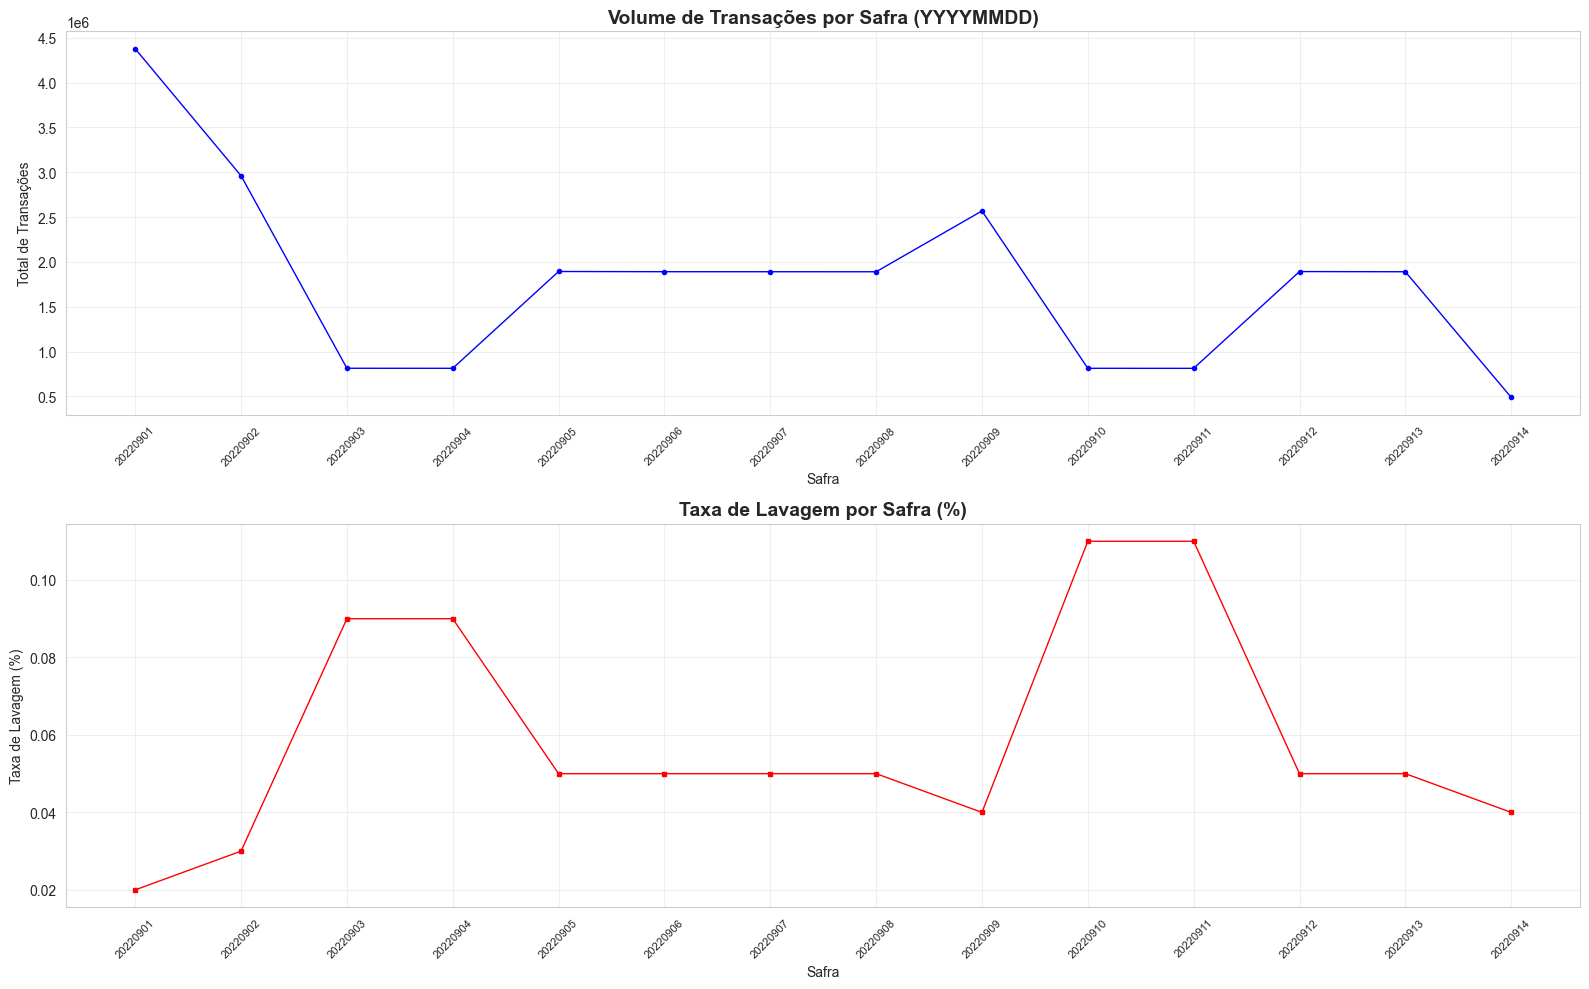

In [16]:
# Análise de distribuição por safra
print("="*80)
print("ANÁLISE DE DISTRIBUIÇÃO POR SAFRA")
print("="*80)

safra_analysis = df_treino_fe.groupby('safra').agg({
    'Is Laundering': ['count', 'sum', 'mean']
}).round(4)

safra_analysis.columns = ['Total_Transacoes', 'Total_Lavagem', 'Taxa_Lavagem']
safra_analysis = safra_analysis.sort_index()

print(f"\n📊 Primeiras 10 safras:")
print(safra_analysis.head(10))

print(f"\n📊 Últimas 10 safras:")
print(safra_analysis.tail(10))

# Visualização
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Gráfico 1: Volume por safra
axes[0].plot(safra_analysis.index.astype(str), safra_analysis['Total_Transacoes'], 
             marker='o', linewidth=1, markersize=3, color='blue')
axes[0].set_title('Volume de Transações por Safra (YYYYMMDD)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Safra')
axes[0].set_ylabel('Total de Transações')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
# Mostrar apenas algumas labels para não ficar muito poluído
n_ticks = min(20, len(safra_analysis))
tick_positions = np.linspace(0, len(safra_analysis)-1, n_ticks, dtype=int)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(safra_analysis.index[tick_positions].astype(str))

# Gráfico 2: Taxa de lavagem por safra
axes[1].plot(safra_analysis.index.astype(str), safra_analysis['Taxa_Lavagem'] * 100, 
             marker='s', linewidth=1, markersize=3, color='red')
axes[1].set_title('Taxa de Lavagem por Safra (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Safra')
axes[1].set_ylabel('Taxa de Lavagem (%)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(safra_analysis.index[tick_positions].astype(str))

plt.tight_layout()
plt.show()

ANÁLISE POR HORA DO DIA

📊 Distribuição por Hora:
      Total_Transacoes  Total_Lavagem  Taxa_Lavagem
hour                                               
0              2984298            500        0.0002
1              1017705            512        0.0005
2              1018382            496        0.0005
3              1017706            504        0.0005
4              1020087            460        0.0005
5               991882            526        0.0005
6               943114            490        0.0005
7               942200            479        0.0005
8               941872            507        0.0005
9               940918            536        0.0006
10              941253            536        0.0006
11              939368            562        0.0006
12              941280            599        0.0006
13              939334            550        0.0006
14              939396            551        0.0006
15              941661            546        0.0006
16            

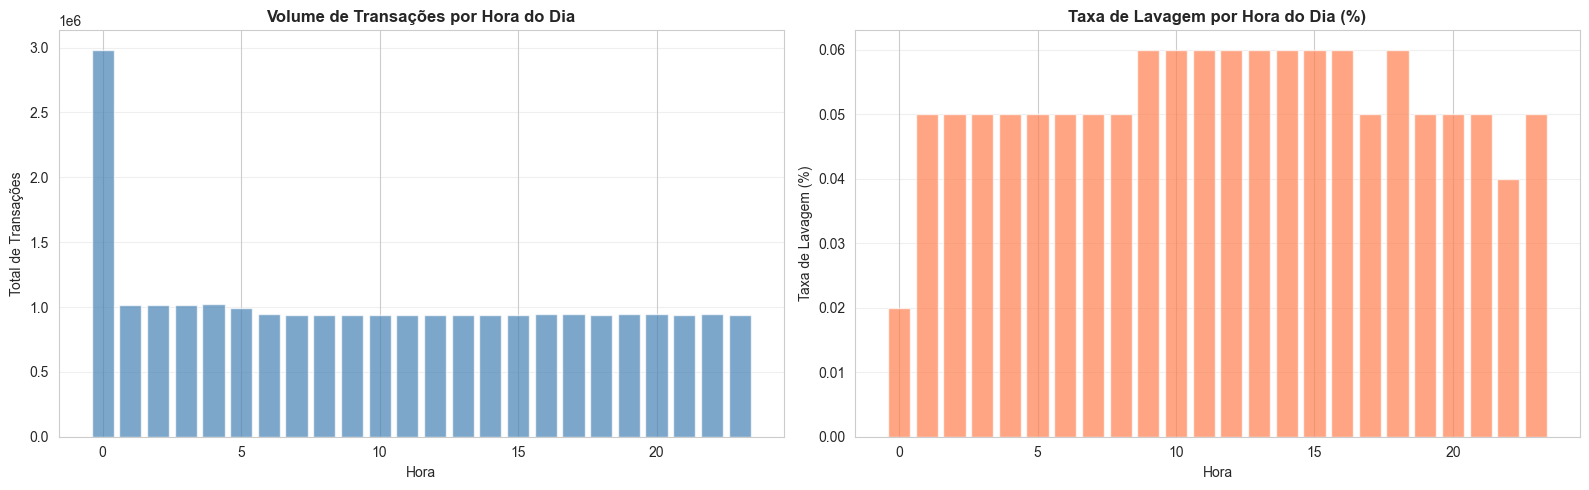

In [17]:
# Estatísticas por hora do dia
print("="*80)
print("ANÁLISE POR HORA DO DIA")
print("="*80)

hour_analysis = df_treino_fe.groupby('hour').agg({
    'Is Laundering': ['count', 'sum', 'mean']
}).round(4)

hour_analysis.columns = ['Total_Transacoes', 'Total_Lavagem', 'Taxa_Lavagem']

print(f"\n📊 Distribuição por Hora:")
print(hour_analysis)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume por hora
axes[0].bar(hour_analysis.index, hour_analysis['Total_Transacoes'], color='steelblue', alpha=0.7)
axes[0].set_title('Volume de Transações por Hora do Dia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Total de Transações')
axes[0].grid(True, alpha=0.3, axis='y')

# Taxa de lavagem por hora
axes[1].bar(hour_analysis.index, hour_analysis['Taxa_Lavagem'] * 100, color='coral', alpha=0.7)
axes[1].set_title('Taxa de Lavagem por Hora do Dia (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Taxa de Lavagem (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

ANÁLISE POR DIA DA SEMANA

📊 Distribuição por Dia da Semana:
         Total_Transacoes  Total_Lavagem  Taxa_Lavagem
Segunda           3785961           1972        0.0005
Terça             3781598           1983        0.0005
Quarta            2380714           1195        0.0005
Quinta            6267438           1876        0.0003
Sexta             5529296           2019        0.0004
Sábado            1628562           1596        0.0010
Domingo           1627617           1617        0.0010


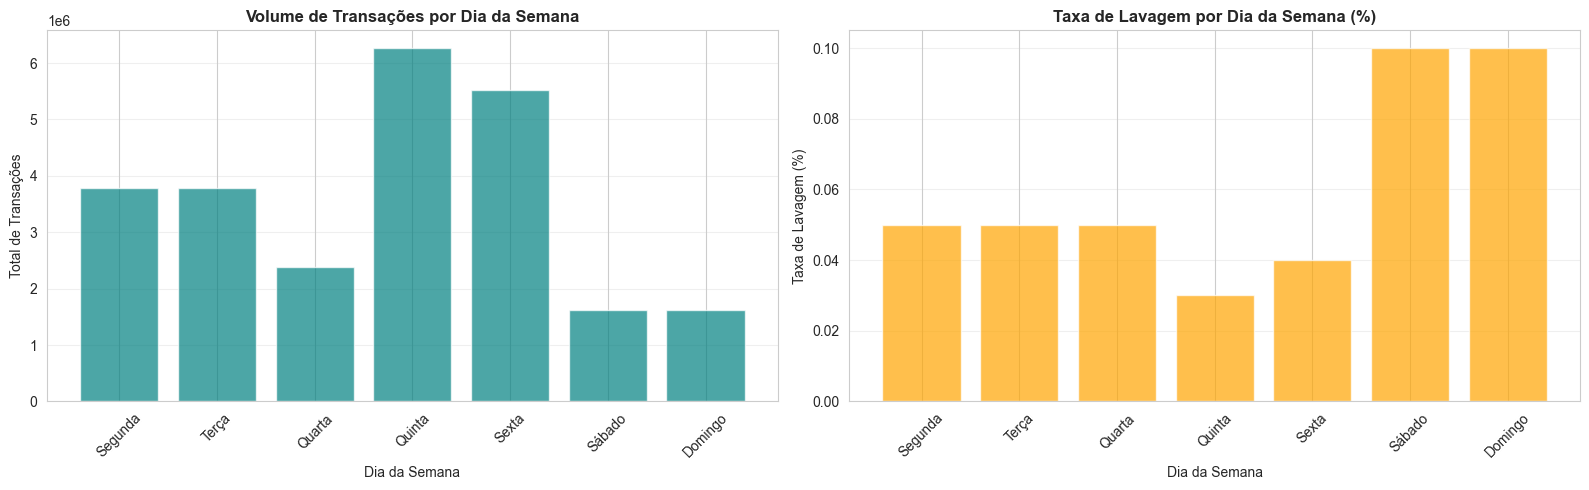

In [18]:
# Análise por dia da semana
print("="*80)
print("ANÁLISE POR DIA DA SEMANA")
print("="*80)

day_names = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

dayofweek_analysis = df_treino_fe.groupby('dayofweek').agg({
    'Is Laundering': ['count', 'sum', 'mean']
}).round(4)

dayofweek_analysis.columns = ['Total_Transacoes', 'Total_Lavagem', 'Taxa_Lavagem']
dayofweek_analysis.index = day_names

print(f"\n📊 Distribuição por Dia da Semana:")
print(dayofweek_analysis)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume por dia da semana
axes[0].bar(dayofweek_analysis.index, dayofweek_analysis['Total_Transacoes'], 
            color='teal', alpha=0.7)
axes[0].set_title('Volume de Transações por Dia da Semana', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Total de Transações')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Taxa de lavagem por dia da semana
axes[1].bar(dayofweek_analysis.index, dayofweek_analysis['Taxa_Lavagem'] * 100, 
            color='orange', alpha=0.7)
axes[1].set_title('Taxa de Lavagem por Dia da Semana (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dia da Semana')
axes[1].set_ylabel('Taxa de Lavagem (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Análise de Features de Negócio

Comparar taxa de lavagem em diferentes períodos (weekend, business hours, night).

ANÁLISE DE FEATURES DE NEGÓCIO

📊 is_weekend:
            Total_Transacoes  Total_Lavagem  Taxa_Lavagem
is_weekend                                               
0                   21745007           9045        0.0004
1                    3256179           3213        0.0010

📊 is_business_hours:
                   Total_Transacoes  Total_Lavagem  Taxa_Lavagem
is_business_hours                                               
0                          16530215           7320        0.0004
1                           8470971           4938        0.0006

📊 is_night:
          Total_Transacoes  Total_Lavagem  Taxa_Lavagem
is_night                                               
0                 16951126           9260        0.0005
1                  8050060           2998        0.0004

📊 is_morning:
            Total_Transacoes  Total_Lavagem  Taxa_Lavagem
is_morning                                               
0                   19352461           9148        0.0005
1             

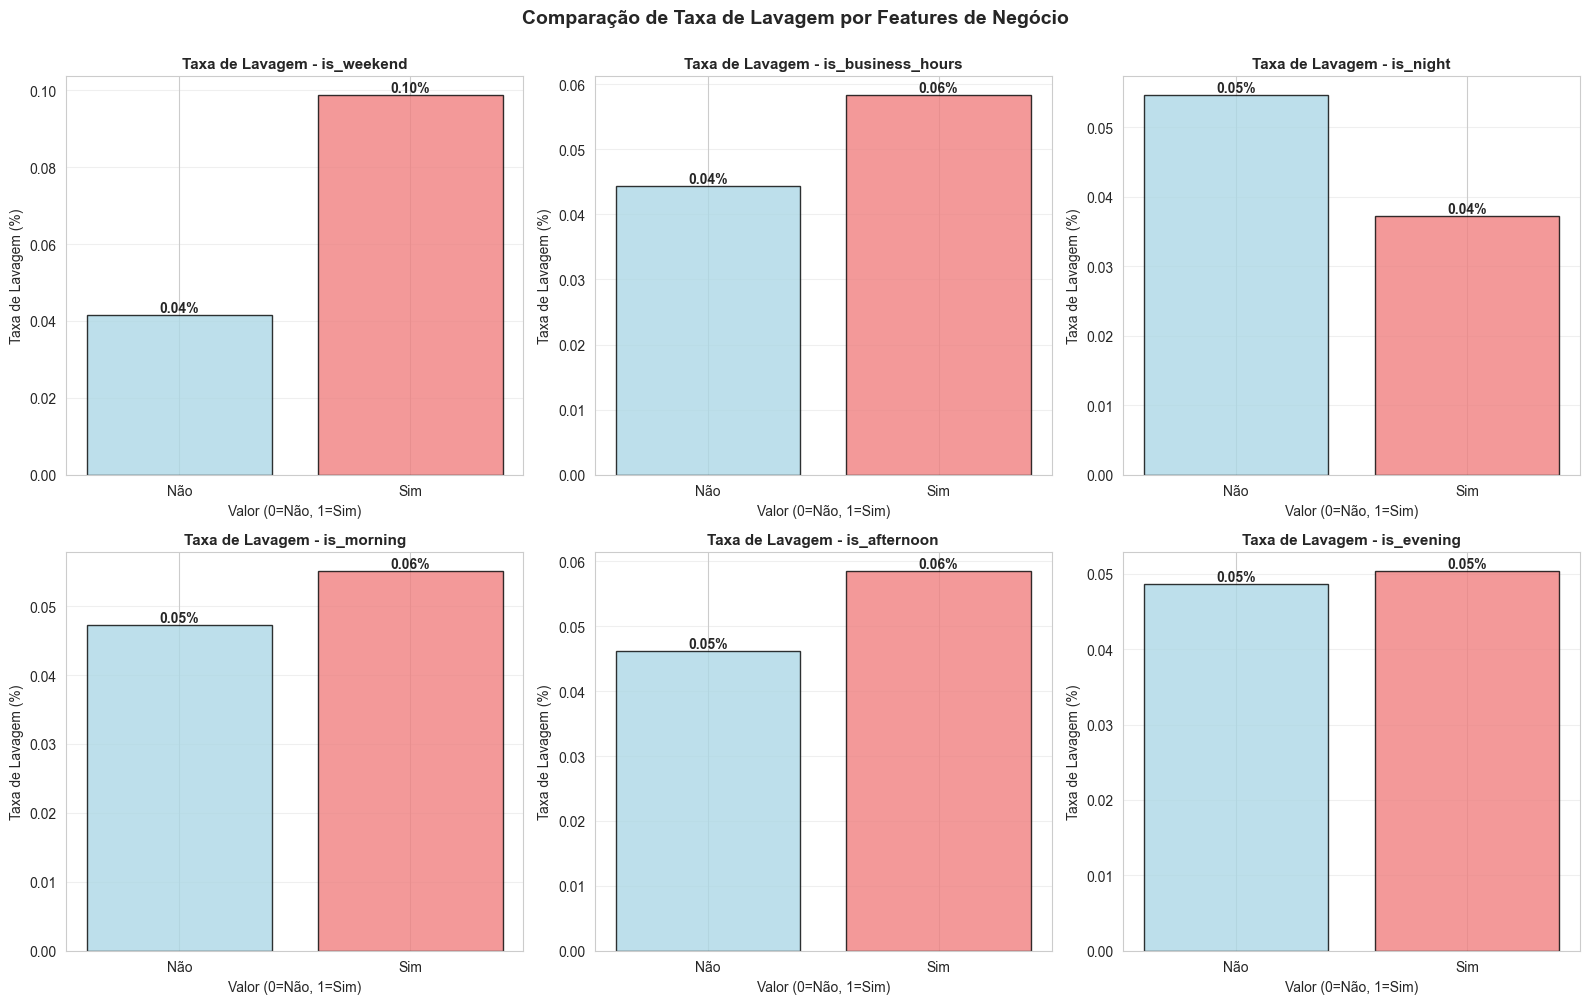

In [19]:
# Análise de features de negócio
business_features = ['is_weekend', 'is_business_hours', 'is_night', 
                     'is_morning', 'is_afternoon', 'is_evening']

print("="*80)
print("ANÁLISE DE FEATURES DE NEGÓCIO")
print("="*80)

for feature in business_features:
    analysis = df_treino_fe.groupby(feature).agg({
        'Is Laundering': ['count', 'sum', 'mean']
    }).round(4)
    
    analysis.columns = ['Total_Transacoes', 'Total_Lavagem', 'Taxa_Lavagem']
    
    print(f"\n📊 {feature}:")
    print(analysis)

# Visualização comparativa
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(business_features):
    ax = axes[idx]
    
    analysis = df_treino_fe.groupby(feature)['Is Laundering'].mean() * 100
    
    colors = ['lightcoral' if i == 1 else 'lightblue' for i in analysis.index]
    ax.bar(analysis.index, analysis.values, color=colors, alpha=0.8, edgecolor='black')
    
    ax.set_title(f'Taxa de Lavagem - {feature}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor (0=Não, 1=Sim)')
    ax.set_ylabel('Taxa de Lavagem (%)')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Não', 'Sim'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adicionar valores nas barras
    for i, v in enumerate(analysis.values):
        ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparação de Taxa de Lavagem por Features de Negócio', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. Salvamento dos Dados com Features Simplificadas

Salvamos os datasets com features temporais para uso nos próximos notebooks.

In [20]:
# Definir caminhos de saída
output_treino = get_data_path('df_treino_with_features.csv', 'processed')
output_oot = get_data_path('df_oot_with_features.csv', 'processed')

# Salvar
print("="*80)
print("SALVAMENTO DOS DADOS")
print("="*80)

df_treino_fe.to_csv(output_treino, index=False)
df_oot_fe.to_csv(output_oot, index=False)

print(f"\n✅ Datasets salvos com sucesso!")
print(f"\n📁 Arquivos:")
print(f"   - {output_treino}")
print(f"   - {output_oot}")

# Verificar tamanhos
size_treino = Path(output_treino).stat().st_size / (1024 * 1024)
size_oot = Path(output_oot).stat().st_size / (1024 * 1024)

print(f"\n📏 Tamanhos:")
print(f"   - Treino: {size_treino:.2f} MB")
print(f"   - OOT: {size_oot:.2f} MB")

# Salvar informações das features
feature_info = {
    'new_features': new_features,
    'total_features': df_treino_fe.shape[1],
    'train_shape': list(df_treino_fe.shape),
    'oot_shape': list(df_oot_fe.shape),
    'timestamp_col': 'Timestamp',
    'safra_col': 'safra',
    'safra_format': 'YYYYMMDD'
}

feature_info_path = get_data_path('feature_engineering_info.json', 'processed')
with open(feature_info_path, 'w') as f:
    json.dump(feature_info, f, indent=4)

print(f"\n✅ Informações das features salvas em:")
print(f"   - {feature_info_path}")

SALVAMENTO DOS DADOS

✅ Datasets salvos com sucesso!

📁 Arquivos:
   - C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\data\processed\df_treino_with_features.csv
   - C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\data\processed\df_oot_with_features.csv

📏 Tamanhos:
   - Treino: 9734.40 MB
   - OOT: 2486.62 MB

✅ Informações das features salvas em:
   - C:\Users\win\OneDrive\Área de Trabalho\TCC\money_laundering\data\processed\feature_engineering_info.json


## 8. Sumário e Próximos Passos

### ✅ Realizações deste Notebook

1. ✅ Criação de **Safra (YYYYMMDD)** para análise temporal
2. ✅ Extração de **componentes temporais** (ano, mês, dia, hora, etc.)
3. ✅ Implementação de **features cíclicas** (sin/cos) para capturar periodicidade
4. ✅ Criação de **features de negócio** (weekend, business hours, night, etc.)
5. ✅ Análise de distribuição por safra, hora e dia da semana
6. ✅ Pipeline **simplificado e eficiente**

### 📊 Estatísticas Finais

- **Features originais**: {df_treino.shape[1]}
- **Features novas**: {len(new_features)}
- **Features totais**: {df_treino_fe.shape[1]}
- **Safras únicas (treino)**: {df_treino_fe['safra'].nunique()}
- **Safras únicas (OOT)**: {df_oot_fe['safra'].nunique()}

### 🔄 Próximos Passos

**Notebook 06**: Pipeline de Transformação Simplificado
- Encoding de variáveis categóricas
- Normalização de variáveis numéricas
- Sem necessidade de features de velocidade complexas

**Notebook 08**: Treinamento de Modelos
- Uso de safras para validação temporal
- Modelos mais simples e interpretáveis
- Foco em padrões temporais e comportamentais básicos

---

**Data**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  
**Status**: ✅ Feature Engineering Simplificado Concluído